In [4]:
import shutil

import duckdb
from networks.cnn_deep import CNNModel
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, s_kappa,s_lambda,s_kl_kvot,u_albumin_krea,u_igg_krea,u_kappa_krea,u_lambda_krea,u_hc_krea,u_kappa,u_lambda,u_kreatinin,label, set, interpretation,gender,age
                 FROM protein_data
                 WHERE observation_nr = 1
                
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

extra_val = train_rows.sample(frac=0.1, random_state=42)
train_rows = train_rows.drop(extra_val.index)
val_rows = pd.concat([val_rows, extra_val], ignore_index=True)

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)

train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]
test_rows = test_rows[test_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

print(f"-----\nAntal utan m-komponent i valideringsdatan: {len(val_rows[val_rows['label'] == 0])}")
print(f"Antal med m-komponent i valideringsdatan: {len(val_rows[val_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = CNN.build_dataloaders(train_rows, val_rows, val_rows)




Antal utan m-komponent i träningsdatan: 16123
Antal med m-komponent i träningsdatan: 2289
-----
Antal utan m-komponent i valideringsdatan: 9084
Antal med m-komponent i valideringsdatan: 403
Total parameters: 320,194


In [ ]:
results = []

best_auc = -1
best_run = None

for run in range(10):
    print(f"Körning {run+1}/10")

    CNN = CNNModel()


    auc = CNN.retrain(
        train_dl=cnn_train_dl,
        val_dl=cnn_val_dl,
        patience=10,
        model_path=f"../models/temp_m_component_{run}.pth"
    )

    results.append({
        "run": run + 1,
        "val_auc": auc
    })

    if auc > best_auc:
        best_auc = auc
        best_run = run + 1
        print(CNN.model_path)
        shutil.copy(
            f"../models/temp_m_component_{run}.pth",
            CNN.model_path
        )

result_df = pd.DataFrame(results)
result_df.to_csv("../results/m_component_runs.csv", index=False)

print(result_df)
print(f"Bästa körning: {best_run}")
print(f"Bästa val AUC: {best_auc:.4f}")

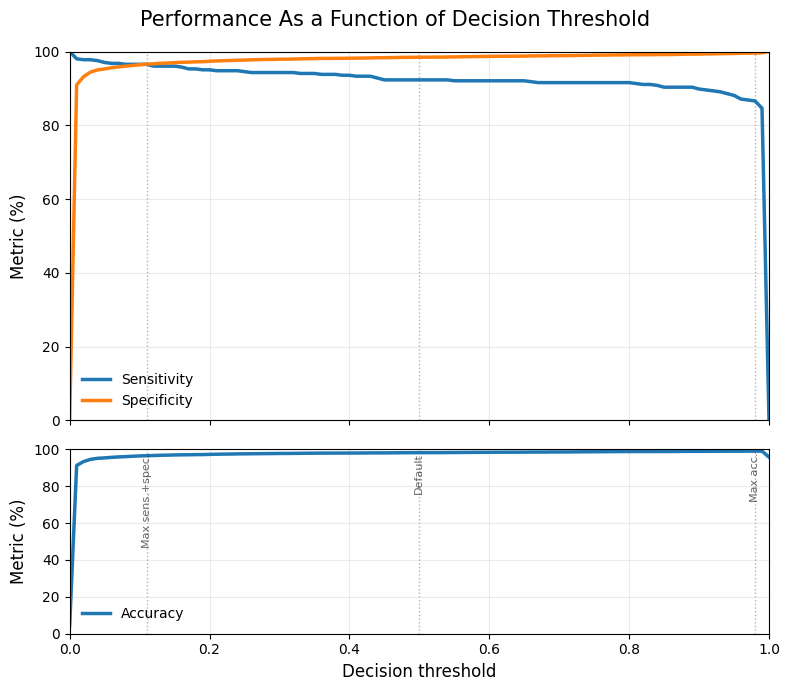

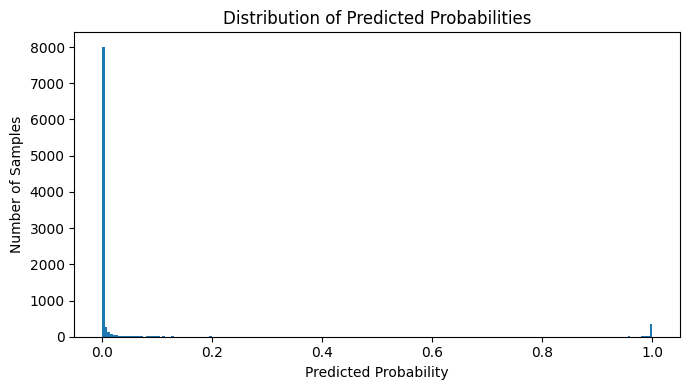

In [5]:
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve
result = CNN.predict(val_rows)

probs  = np.array(result['cnn_probability'])
labels = np.array(result['label'])

fpr, tpr, _ = roc_curve(labels, probs)

thresholds = np.linspace(0, 1, 101)
rows = []
for threshold in thresholds:
    
    preds = (probs > threshold).astype(int) 

    fp = sum((labels == 0) & (preds == 1))
    fn = sum((labels == 1) & (preds == 0))
    tn = sum((labels == 0) & (preds == 0))
    tp = sum((labels == 1) & (preds == 1))


    fn_rate = fn / sum(labels == 1)
    fp_rate = fp / sum(labels == 0)
    accuracy = sum(preds == labels) / len(preds)
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    rows.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "fn_rate": fn_rate,
        "fp_rate": fp_rate,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    })
threshold_df = pd.DataFrame(rows)


plot_df = threshold_df.copy()

# Omvandla till procent
for col in ["accuracy", "sensitivity", "specificity",
            "fp_rate", "fn_rate"]:
    plot_df[col] *= 100

# Viktiga trösklar
t_default = 0.5
t_acc = plot_df.loc[plot_df["accuracy"].idxmax(), "threshold"]
t_bal = plot_df.loc[
    (plot_df["sensitivity"] + plot_df["specificity"]).idxmax(),
    "threshold"
]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# ----------------------------
# Övre panel
# ----------------------------

ax1.plot(
    plot_df["threshold"],
    plot_df["sensitivity"],
    lw=2.5,
    label="Sensitivity"
)

ax1.plot(
    plot_df["threshold"],
    plot_df["specificity"],
    lw=2.5,
    label="Specificity"
)

ax1.set_ylabel("Metric (%)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.grid(alpha=0.25)
ax1.legend(frameon=False)

# ----------------------------
# Nedre panel
# ----------------------------

ax2.plot(
    plot_df["threshold"],
    plot_df["accuracy"],
    lw=2.5,
    label="Accuracy"
)


ax2.set_xlabel("Decision threshold", fontsize=12)
ax2.set_ylabel("Metric (%)", fontsize=12)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 100)
ax2.grid(alpha=0.25)
ax2.legend(frameon=False)

# ----------------------------
# Diskreta markeringar
# ----------------------------

markers = [
    (t_default, "Default"),
    (t_acc, "Max acc."),
    (t_bal, "Max sens.+spec.")
]

for ax in [ax1, ax2]:
    for x, _ in markers:
        ax.axvline(
            x,
            color="black",
            linestyle=":",
            linewidth=1,
            alpha=0.3,
            zorder=0
        )

# Text endast i nedersta figuren
for x, text in markers:
    ax2.text(
        x,
        98,
        text,
        rotation=90,
        fontsize=8,
        alpha=0.6,
        ha="center",
        va="top"
    )

plt.suptitle(
    "Performance As a Function of Decision Threshold",
    fontsize=15,
    y=0.98
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))

plt.hist(probs, bins=200)
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Samples")
plt.title("Distribution of Predicted Probabilities")

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

     Negativ       1.00      0.96      0.98      9084
     Positiv       0.54      0.97      0.69       403

    accuracy                           0.96      9487
   macro avg       0.77      0.96      0.84      9487
weighted avg       0.98      0.96      0.97      9487

[[8756  328]
 [  14  389]]


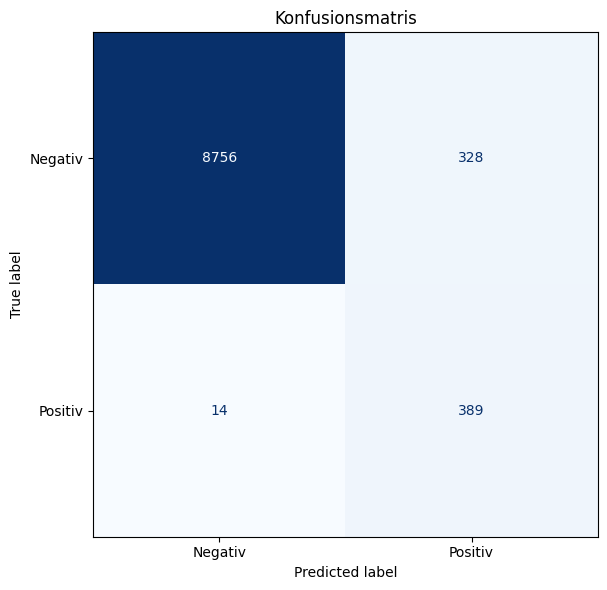

AUC: 0.9941452153760928
Accuracy:  96.40%
FN-rate:   3.47%  (farliga missade fall)
FP-rate:   3.61%  (onödiga larm)
Sensitivitet:   96.53%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   96.39%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9941


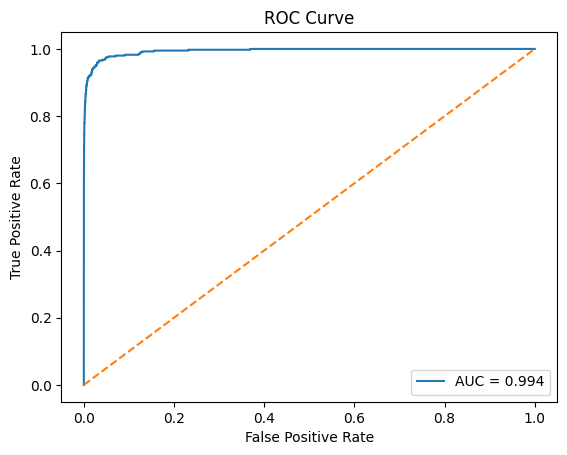

In [6]:
df = CNN.predict(val_rows)
df,_ = CNN.evaluate(val_rows,threshold=0.1)


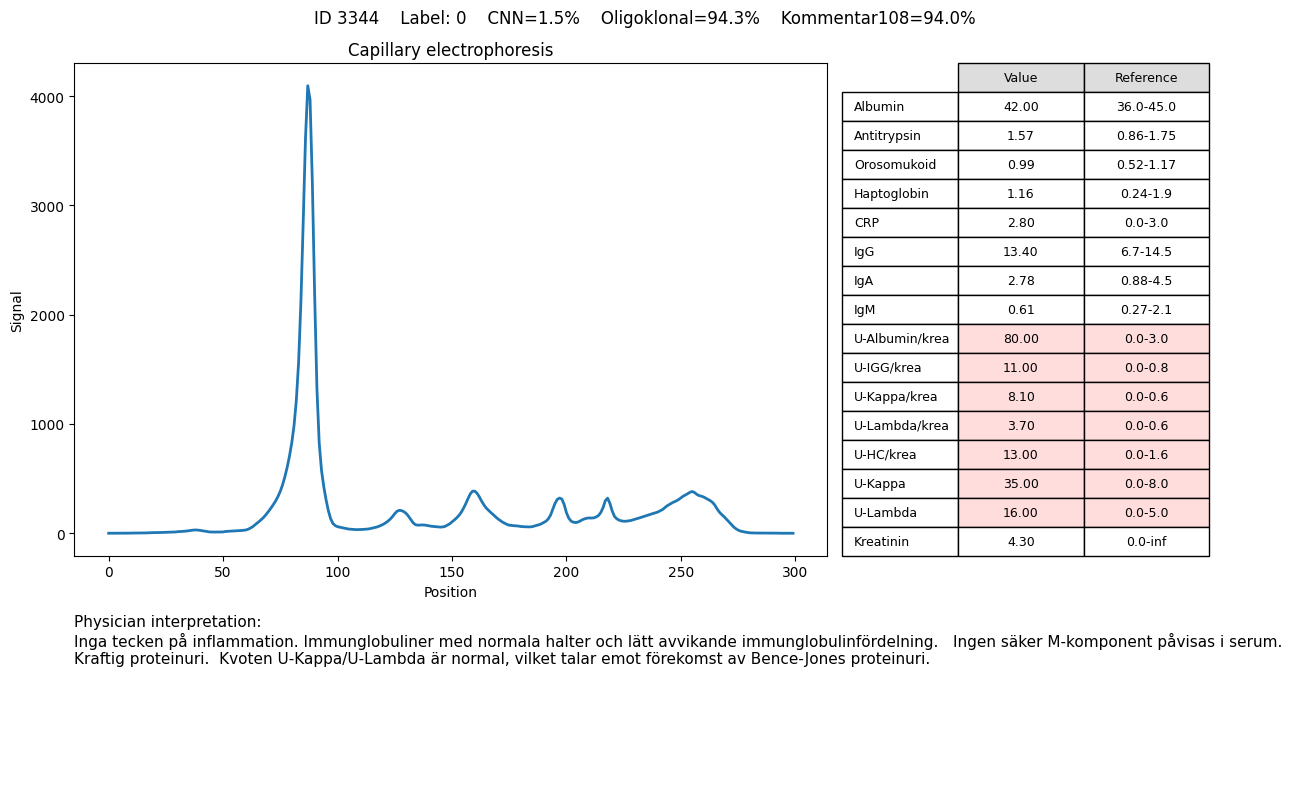

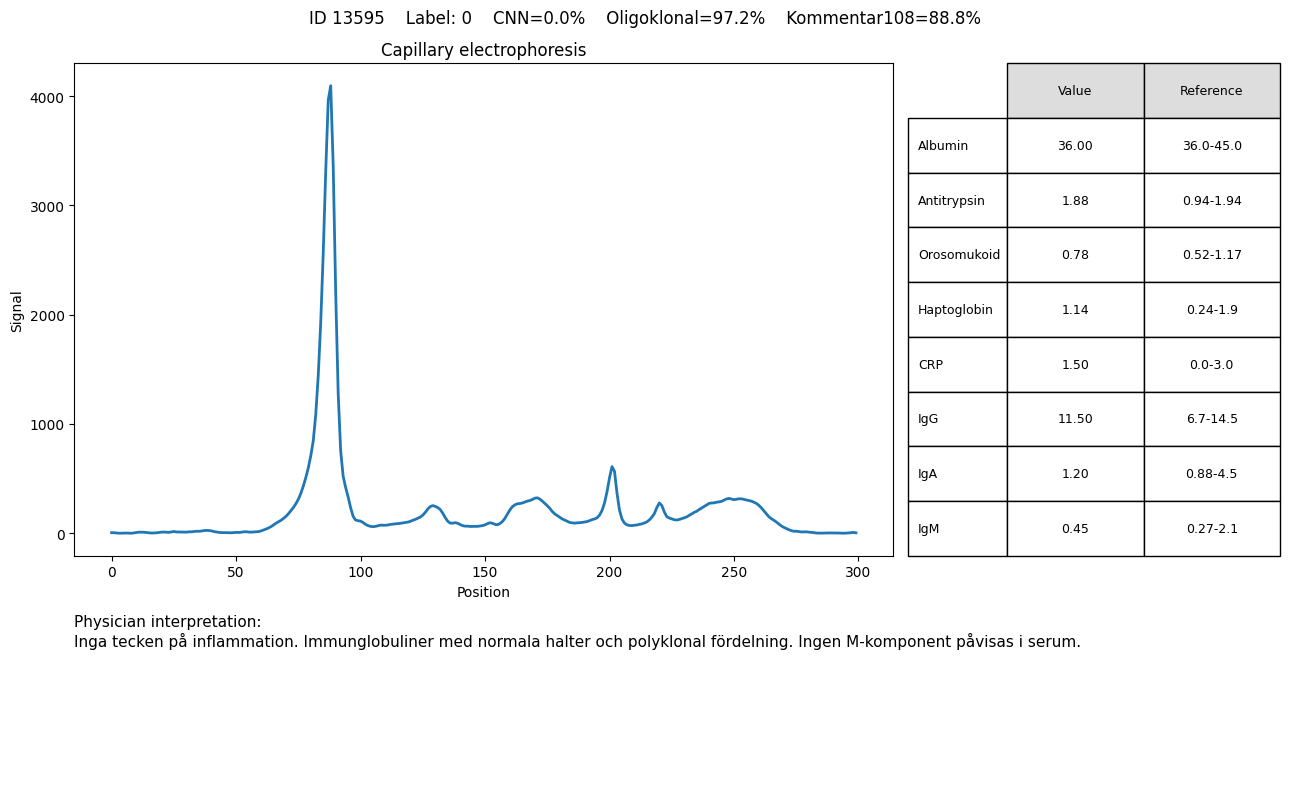

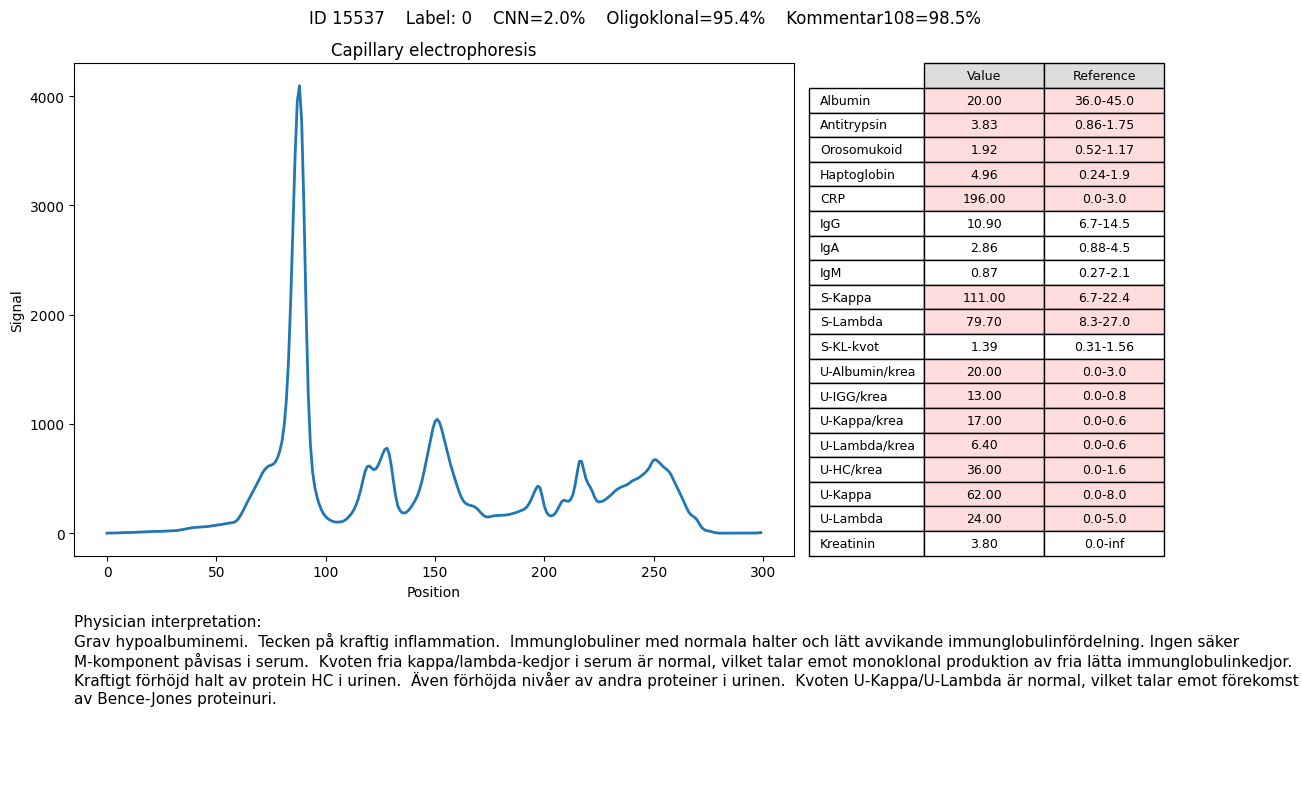

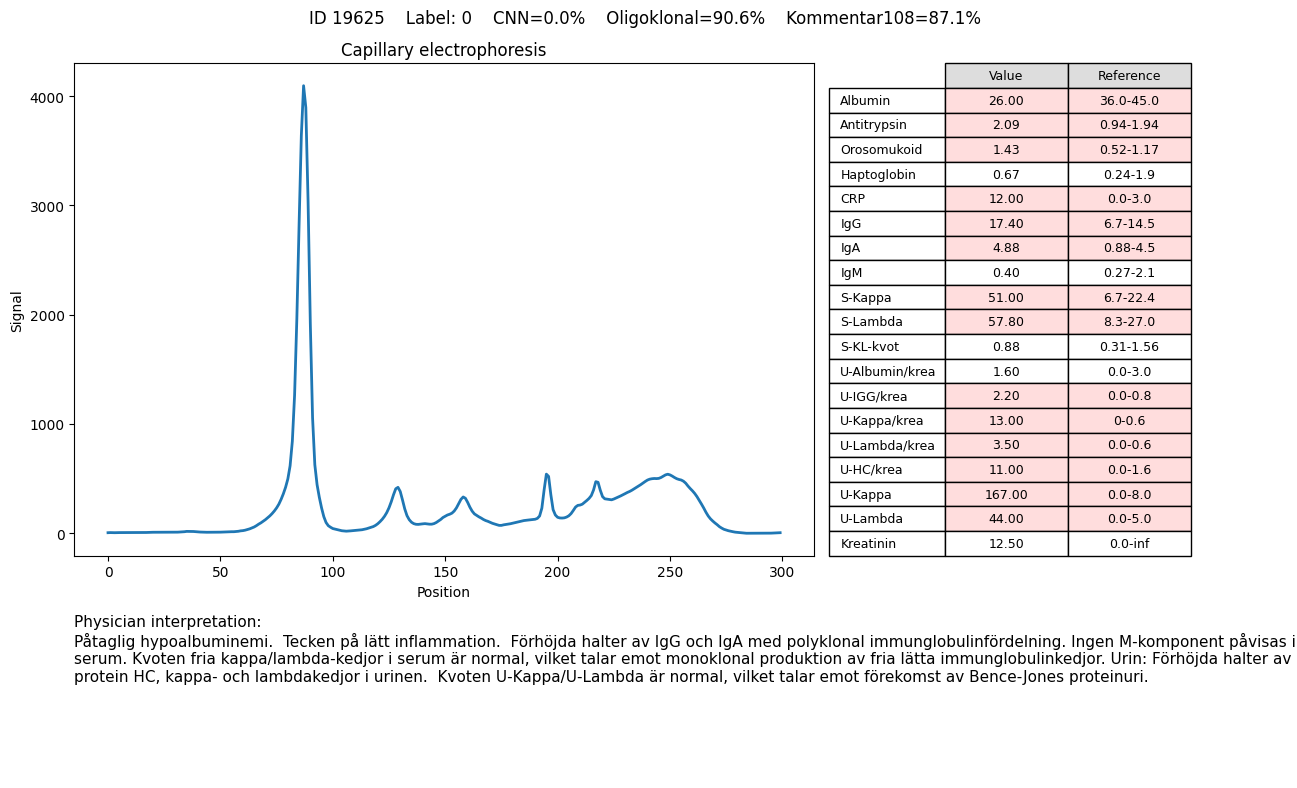

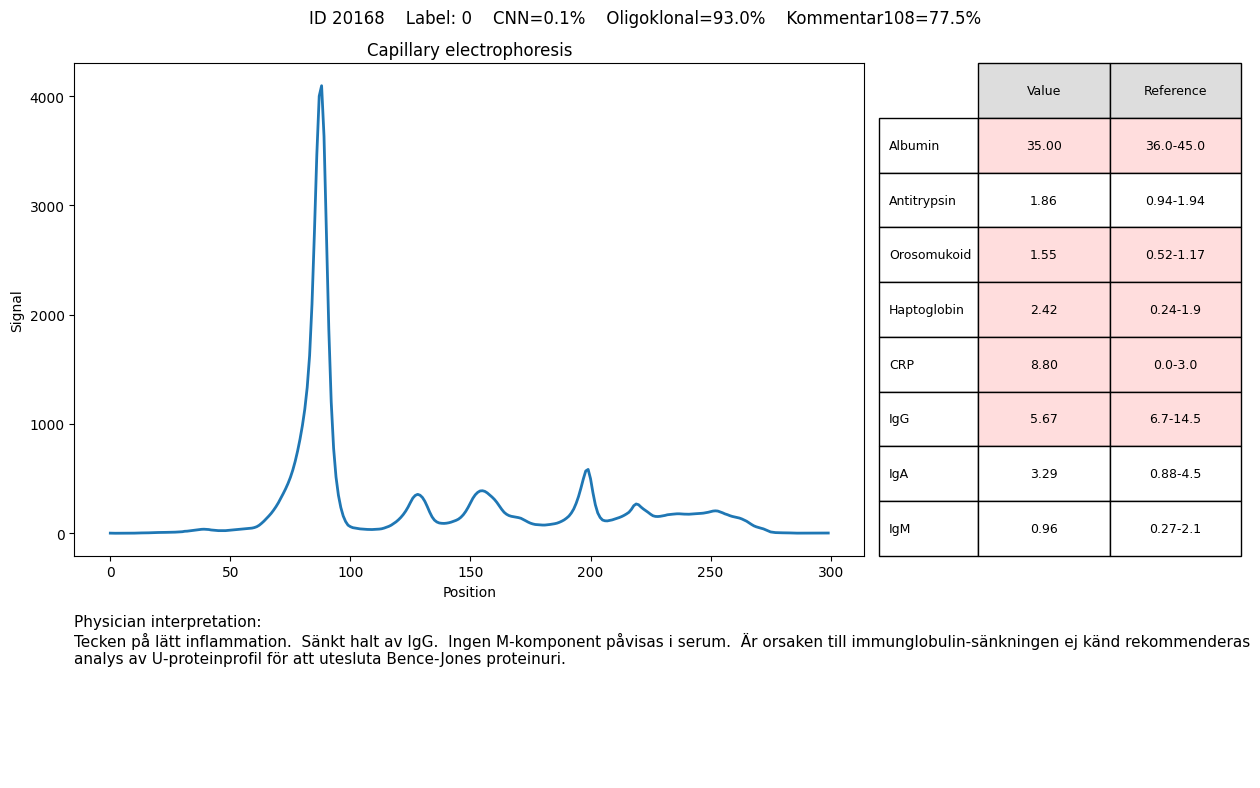

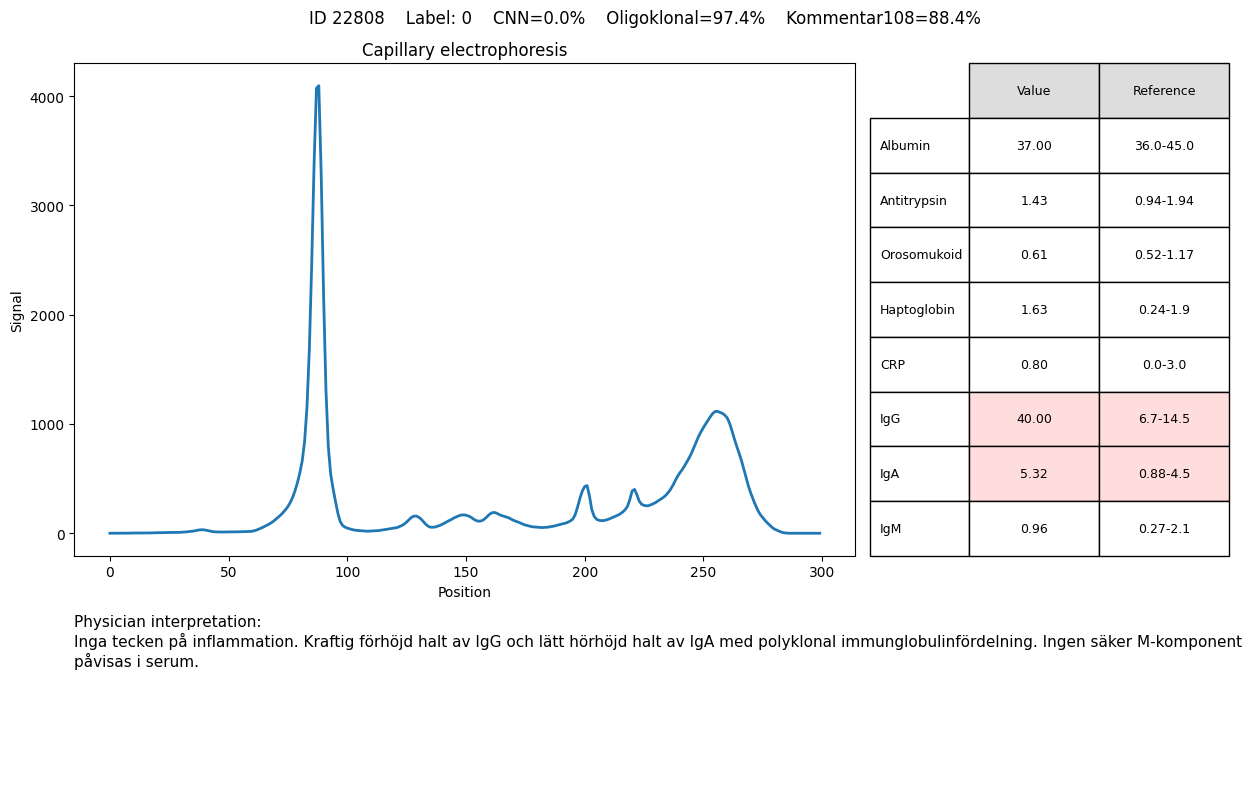

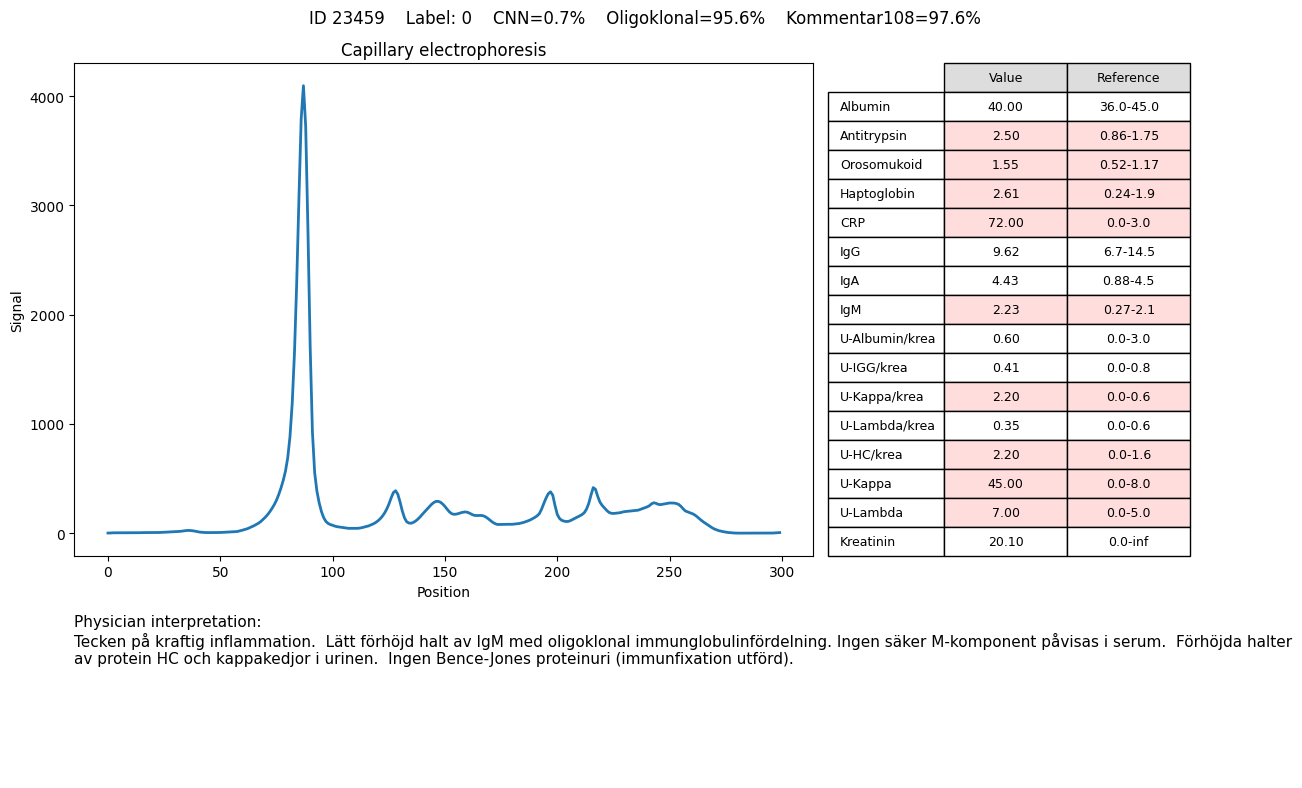

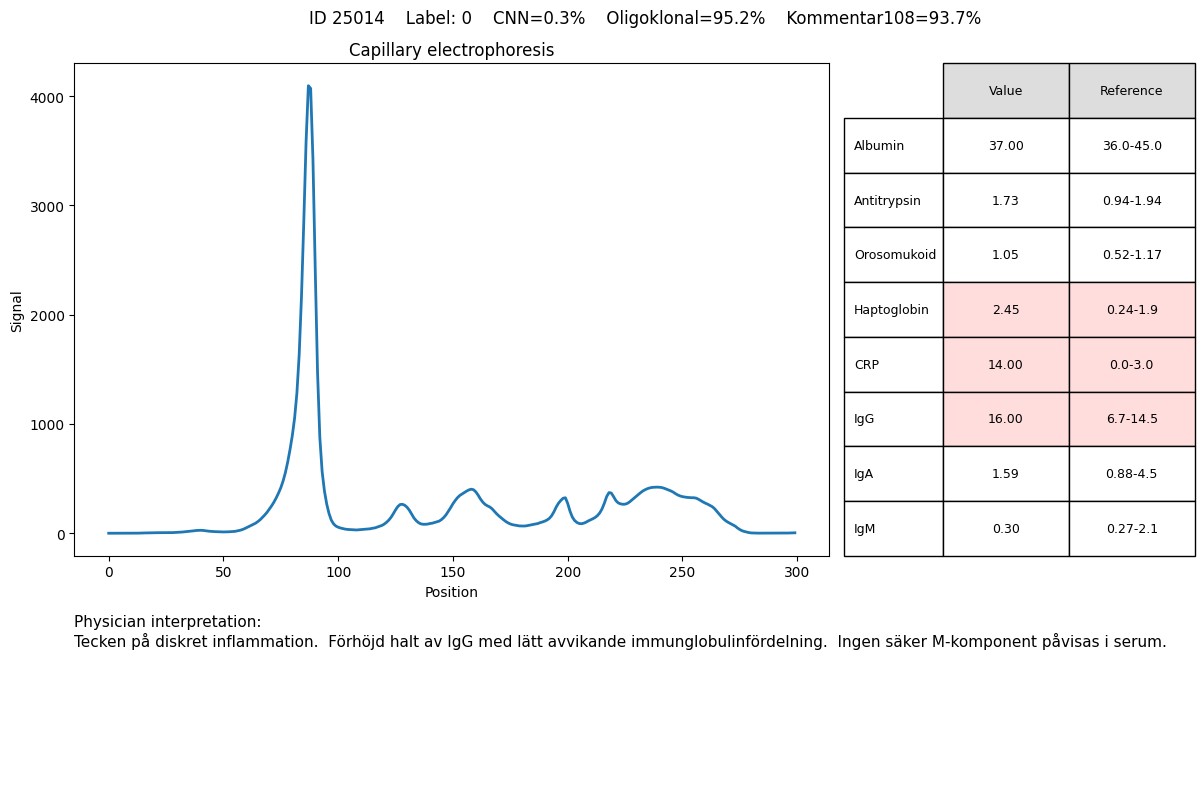

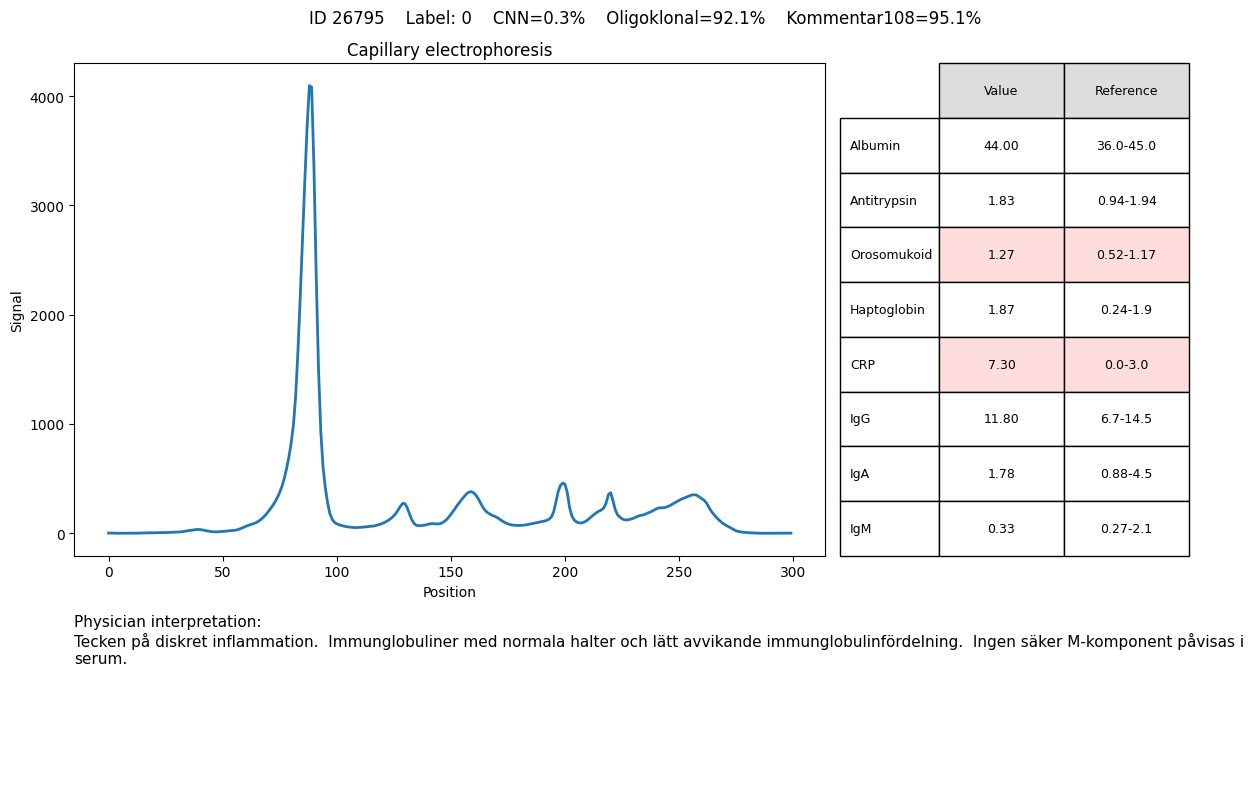

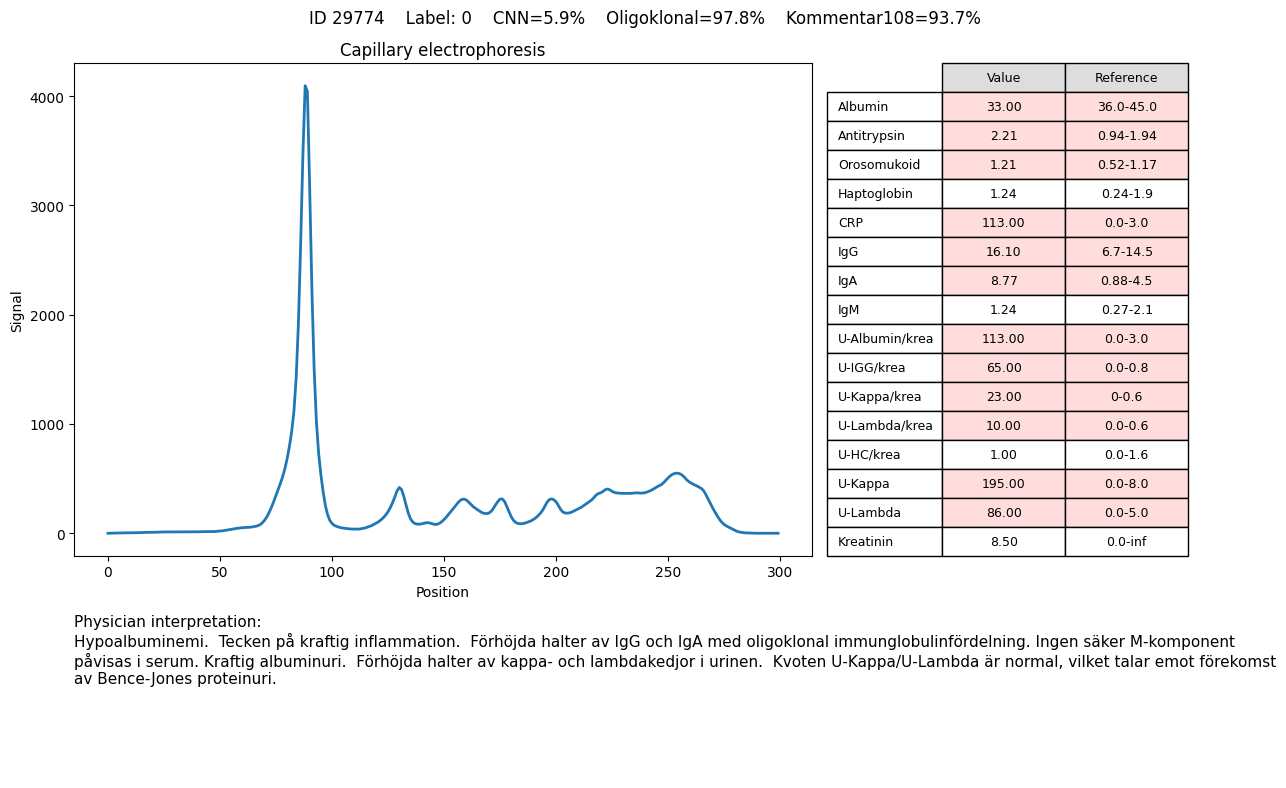

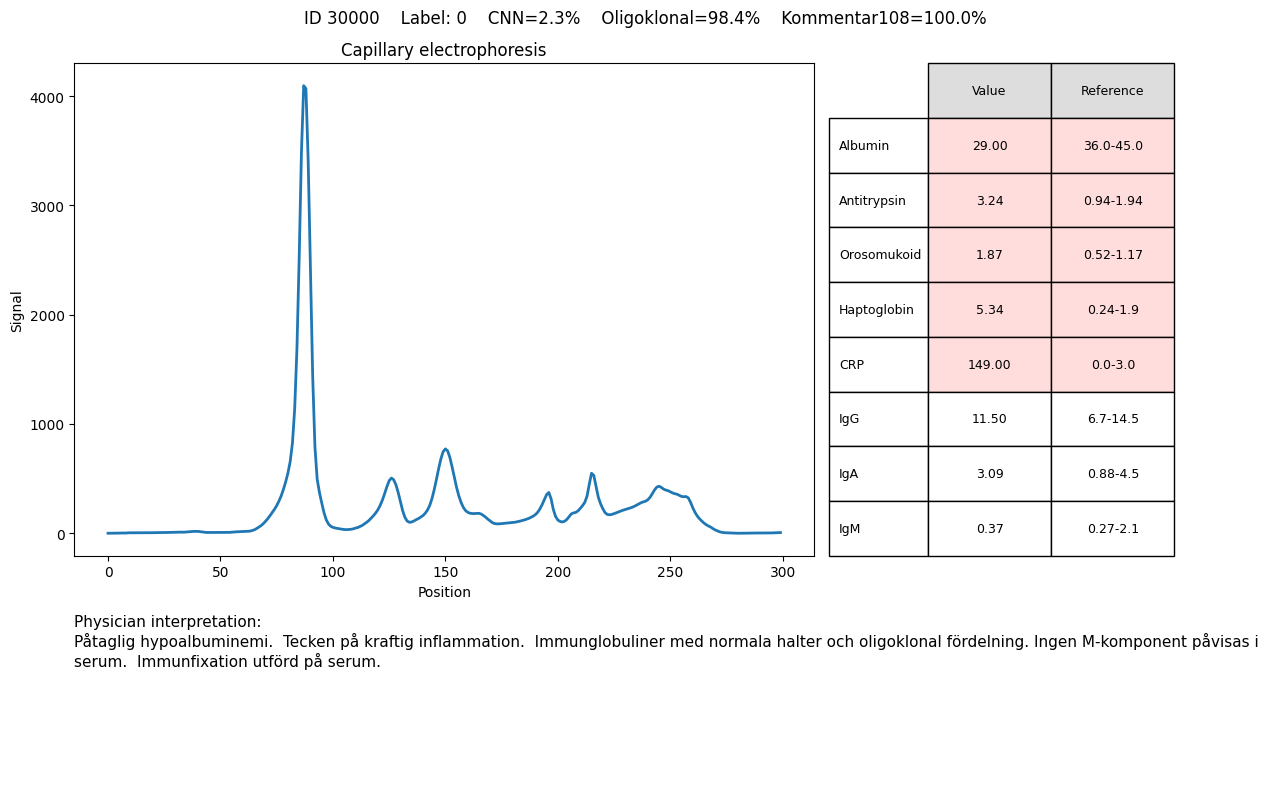

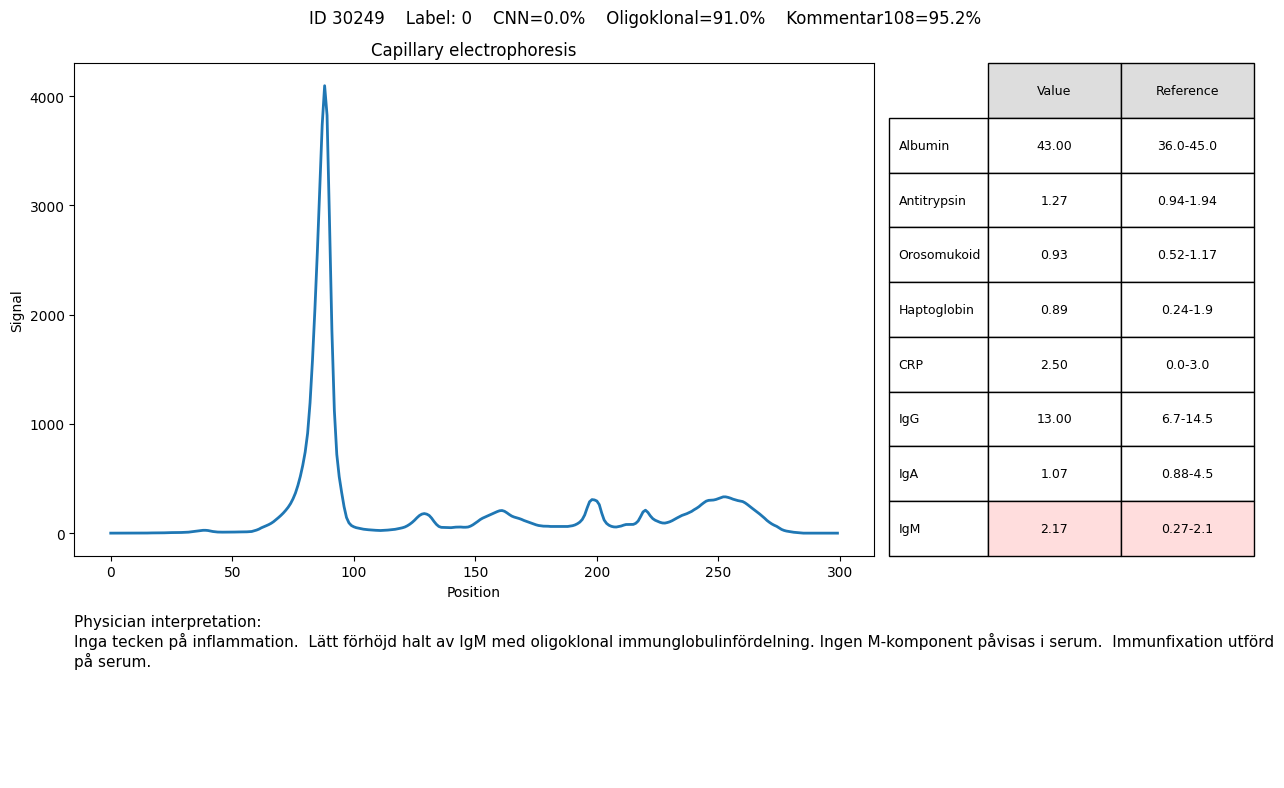

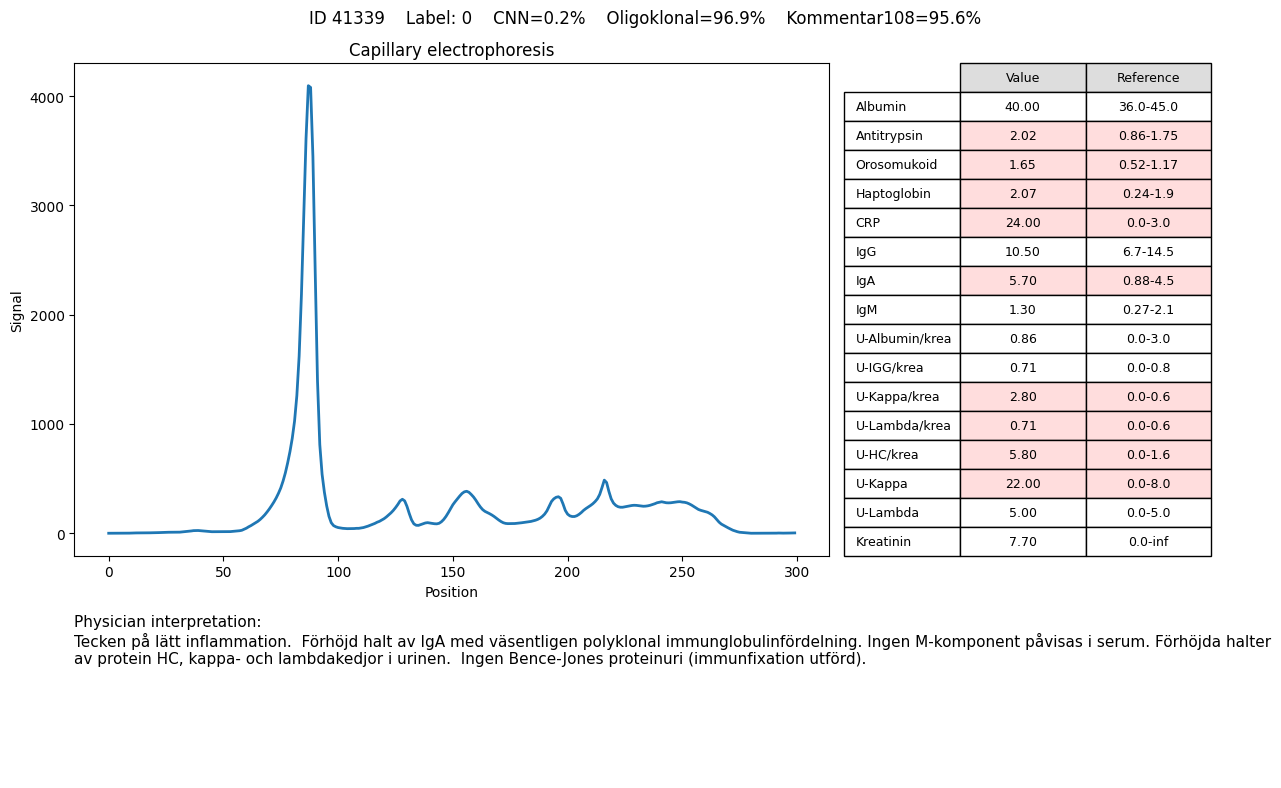

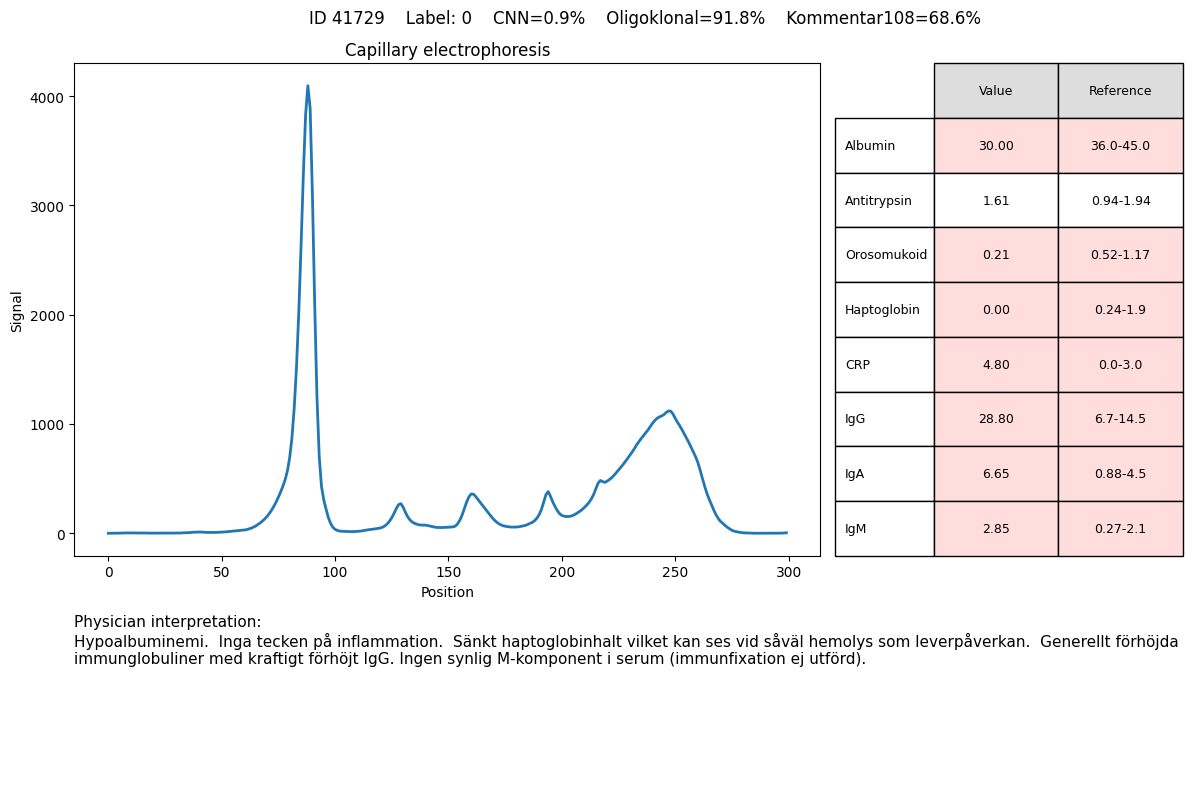

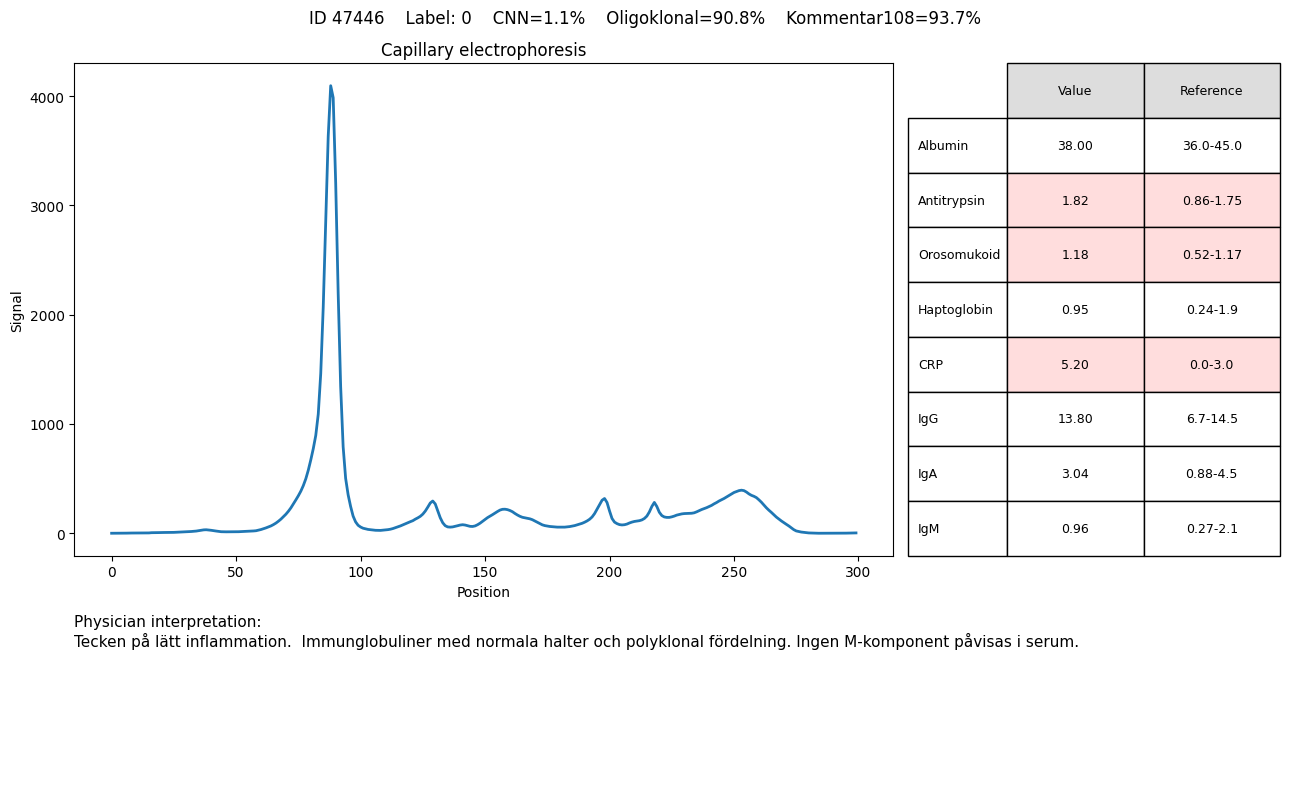

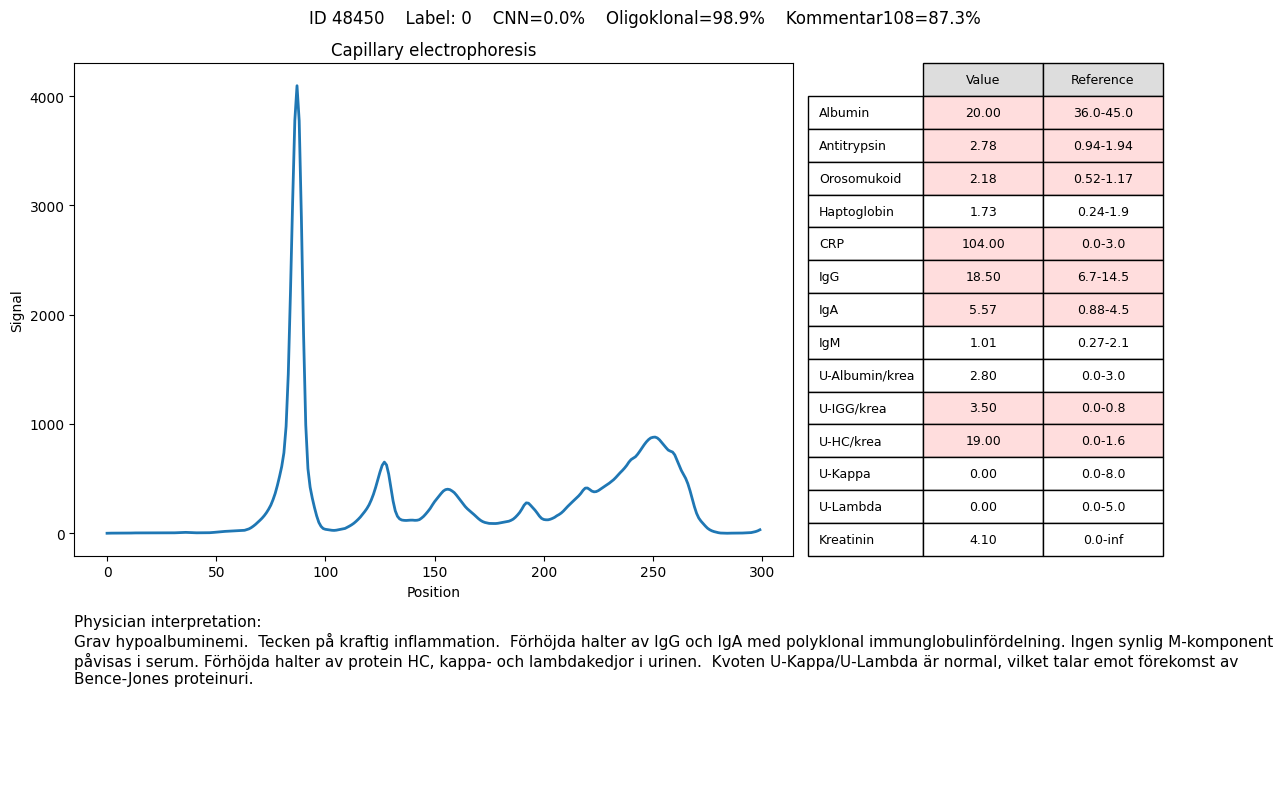

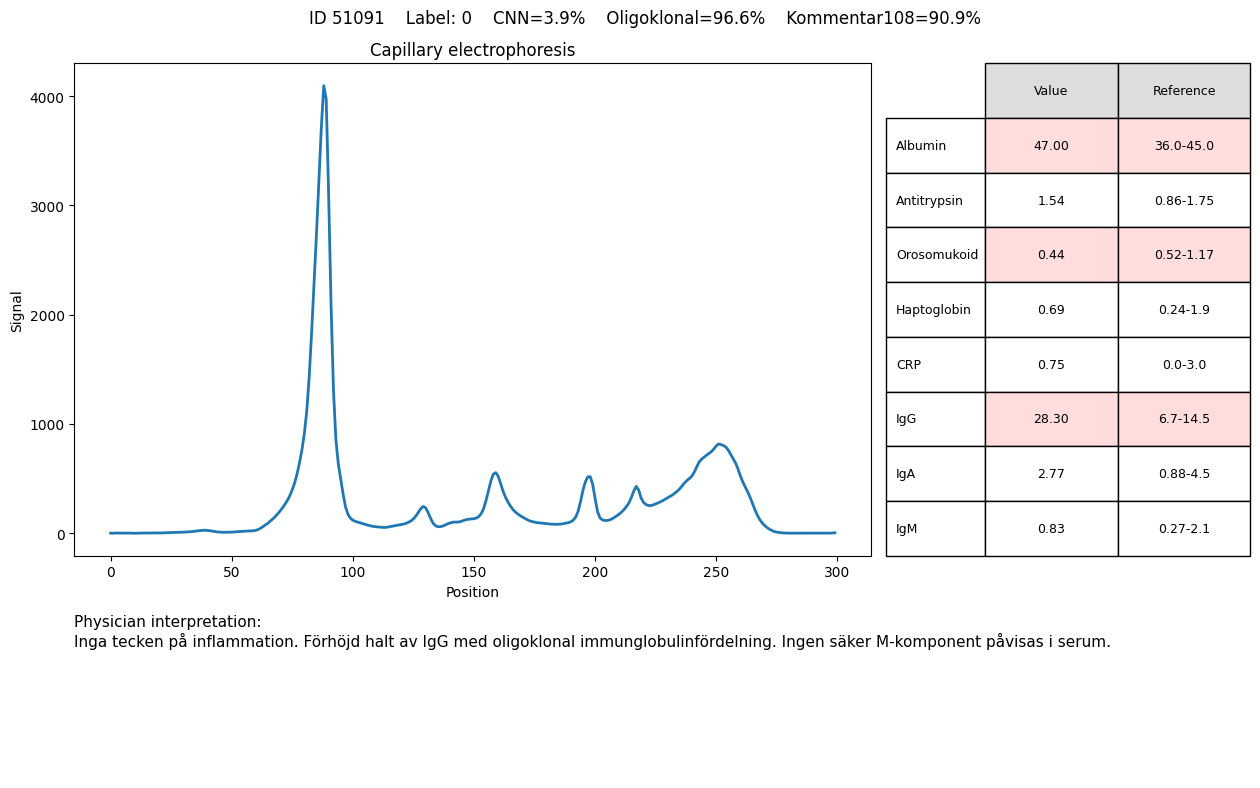

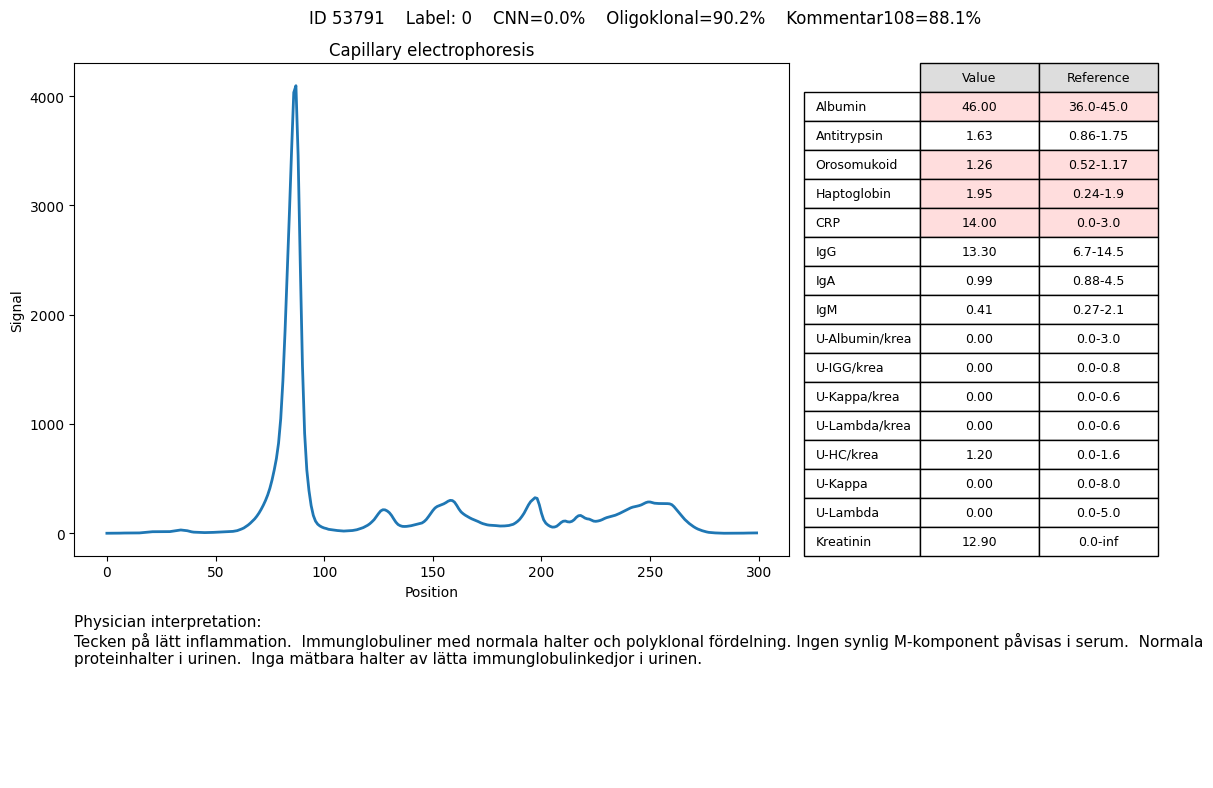

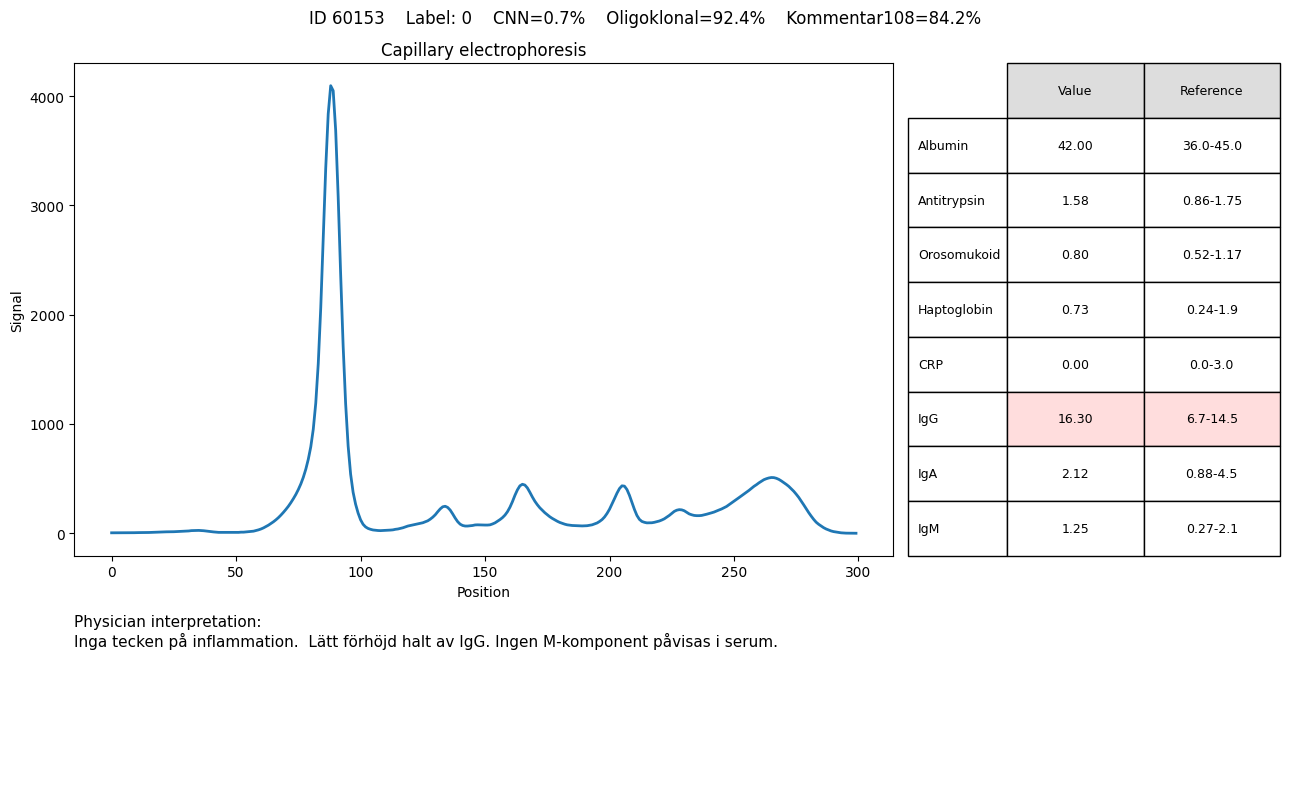

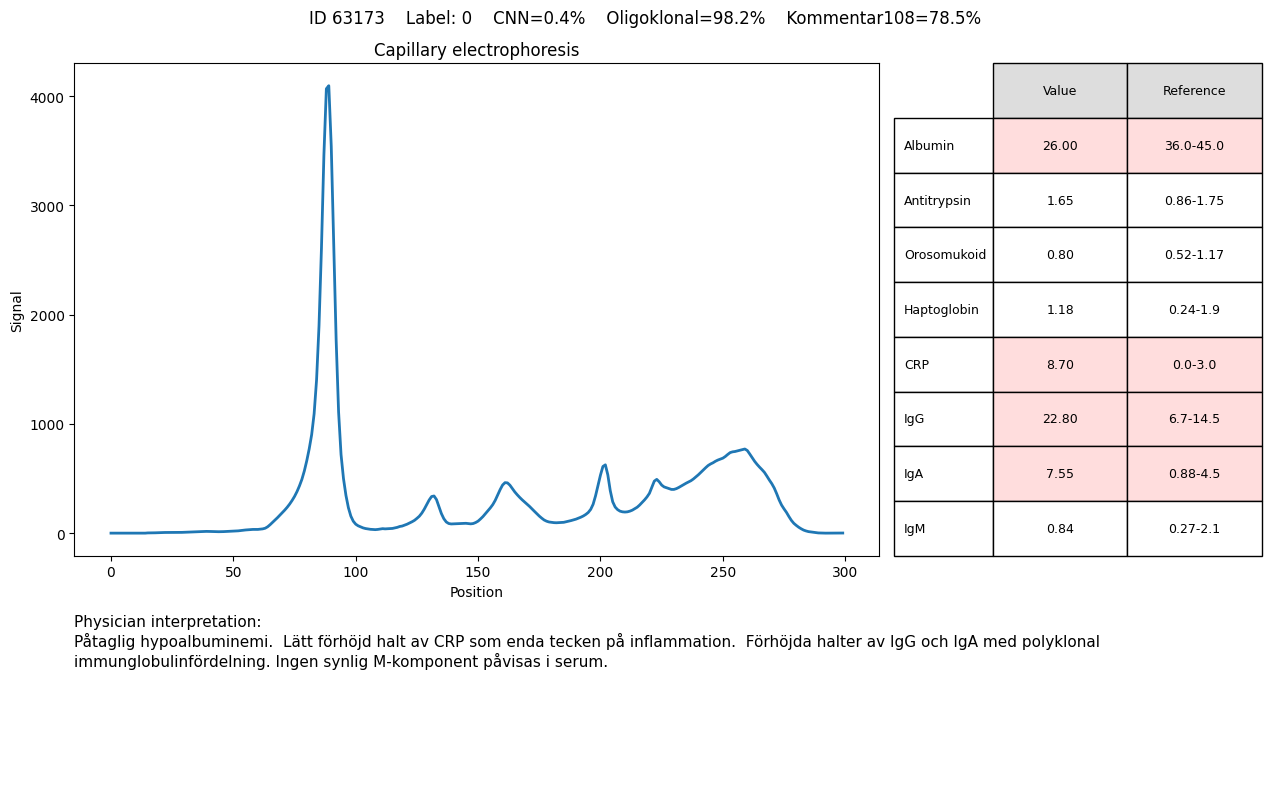

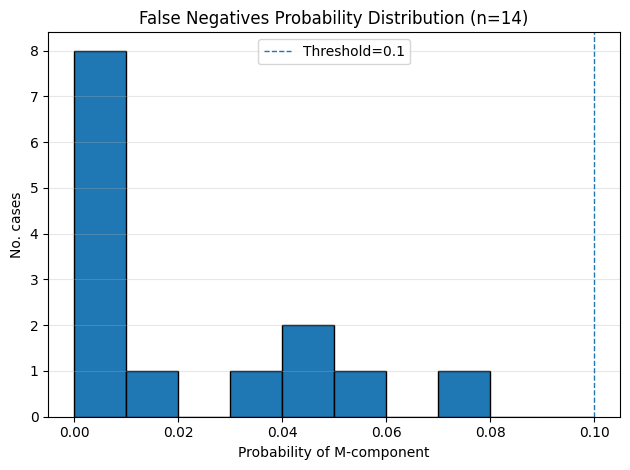

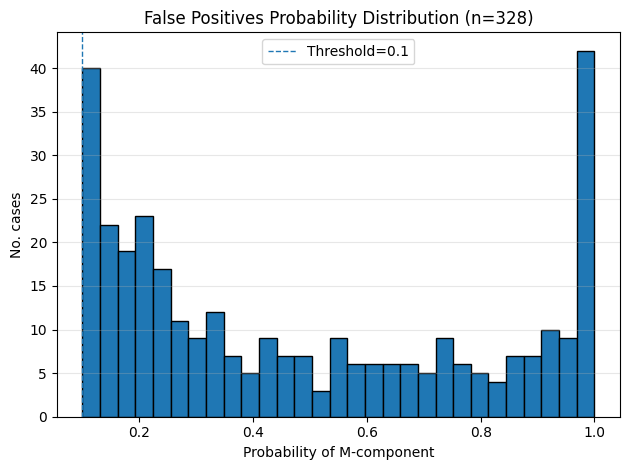

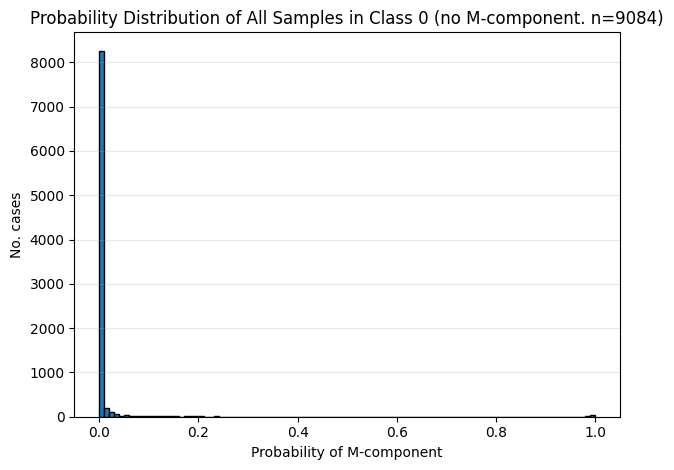

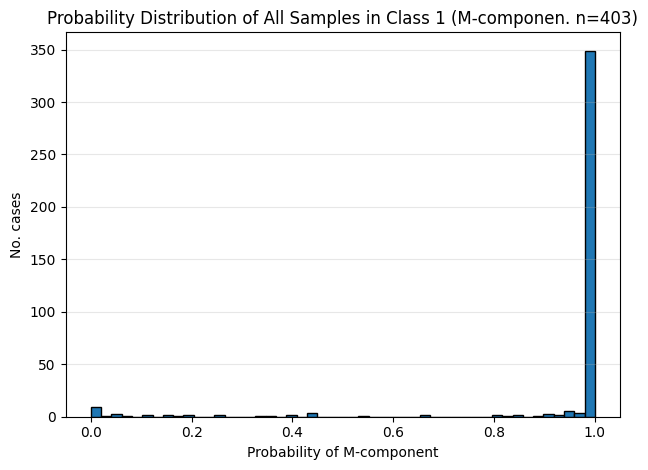

In [ ]:
from functions.evaluation import show_case
from networks.oligoclonal_network import OligoclonalModel
from networks.comment_108 import Comment108Model
df = OligoclonalModel().predict(df)
df = Comment108Model().predict(df)

df['prediction'] = (df['cnn_probability'] >= 0.1).astype(int)


fn_rows = df[ (df['label'] == 1) & (df['prediction'] == 0)]
fp_rows = df[ (df['label'] == 0) & (df['prediction'] == 1)]
tn_rows = df[ (df['label'] == 0)]
tp_rows = df[ (df['label'] == 1)]

for _, row in df[(df['oligoclonal_probability'] > 0.9) & (df['cnn_probability'] < 0.2)].head(20).iterrows():
    show_case(row.to_frame().T.reset_index(drop=True))
    plt.show()


plt.hist(fn_rows['cnn_probability'], bins=np.linspace(0, 0.1, 11), edgecolor='black')

plt.axvline(0.1, linestyle='--', linewidth=1, label='Threshold=0.1')

plt.xlabel("Probability of M-component")
plt.ylabel("No. cases")
plt.title(f"False Negatives Probability Distribution (n={len(fn_rows)})")
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

plt.hist(fp_rows['cnn_probability'], bins=np.linspace(0.1, 1.0, 30), edgecolor='black')

plt.axvline(0.1, linestyle='--', linewidth=1, label='Threshold=0.1')

plt.xlabel("Probability of M-component")
plt.ylabel("No. cases")
plt.title(f"False Positives Probability Distribution (n={len(fp_rows)})")
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

plt.hist(tn_rows['cnn_probability'], bins=np.linspace(0.0, 1.0, 100), edgecolor='black')
plt.xlabel("Probability of M-component")
plt.ylabel("No. cases")
plt.title(f"Probability Distribution of All Samples in Class 0 (no M-component. n={len(tn_rows)})")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.hist(tp_rows['cnn_probability'], bins=np.linspace(0.0, 1.0, 50), edgecolor='black')
plt.xlabel("Probability of M-component")
plt.ylabel("No. cases")
plt.title(f"Probability Distribution of All Samples in Class 1 (M-componen. n={len(tp_rows)})")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()